In [1]:
!pip install roboflow
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip install Ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 66.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 67.9 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
Looking in indexes: https://download.pytorch.org/whl/cu121
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 59.1 MB/s eta 0:00:00


In [3]:
from roboflow import Roboflow
from ultralytics import YOLO
from IPython.display import Image as IPyImage, display, HTML
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import glob
import os
from ipywidgets import HBox, Image as WImage
import base64
from collections import Counter
from collections import defaultdict
from PIL import Image
import yaml
import cv2
from io import BytesIO
from tqdm import tqdm
import albumentations as A

In [3]:
rf = Roboflow(api_key="YBaBoieNSNnA7fkaAghG")
project = rf.workspace("chiheb").project("fire-and-smoke-detection-orehk")
version = project.version(5)
dataset = version.download("yolov12")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to fire-and-smoke-detection-5 in yolov12:: 100%|██████████| 43909/43909 [00:07<00:00, 5759.38it/s] 


In [4]:
labels_dir = "/content/fire-and-smoke-detection-5/train/labels"
data_yaml = "/content/fire-and-smoke-detection-5/data.yaml"

with open(data_yaml) as f:
    data = yaml.safe_load(f)
names = data["names"]

counts = Counter()
for file in os.listdir(labels_dir):
    with open(os.path.join(labels_dir, file)) as f:
        for line in f:
            cls_id = int(line.split()[0])
            counts[cls_id] += 1

for cls_id, count in sorted(counts.items(), key=lambda x: x[1], reverse=True):
    print(f"{names[cls_id]:<20} : {count}")

fire                 : 14911
smoke                : 14158


In [ ]:
model = YOLO("/content/last.pt")
train_results = model.train(
    data=data_yaml,
    epochs=60,
    imgsz=640,
    batch=96,
    patience=7,
    lr0=0.001,
    optimizer="auto",
    resume=True
)

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=96, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/fire-and-smoke-detection-5/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/last.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pa

In [4]:
data_yaml = "/content/fire-and-smoke-detection-5/data.yaml"
model = YOLO("/content/runs/detect/train/weights/best.pt")
model.val(data=data_yaml)

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,542 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 15.5±7.0 MB/s, size: 37.5 KB)
val: Scanning /content/fire-and-smoke-detection-5/test/labels.cache... 2645 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2645/2645 462.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 166/166 5.9it/s 28.2s
                   all       2645       3852      0.734      0.701      0.745      0.409
                  fire       1415       2061      0.679      0.567      0.639      0.323
                 smoke       1711       1791      0.789      0.834      0.851      0.494
Speed: 1.4ms preprocess, 3.7ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to /content/runs/detect/val


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b4beb121790>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

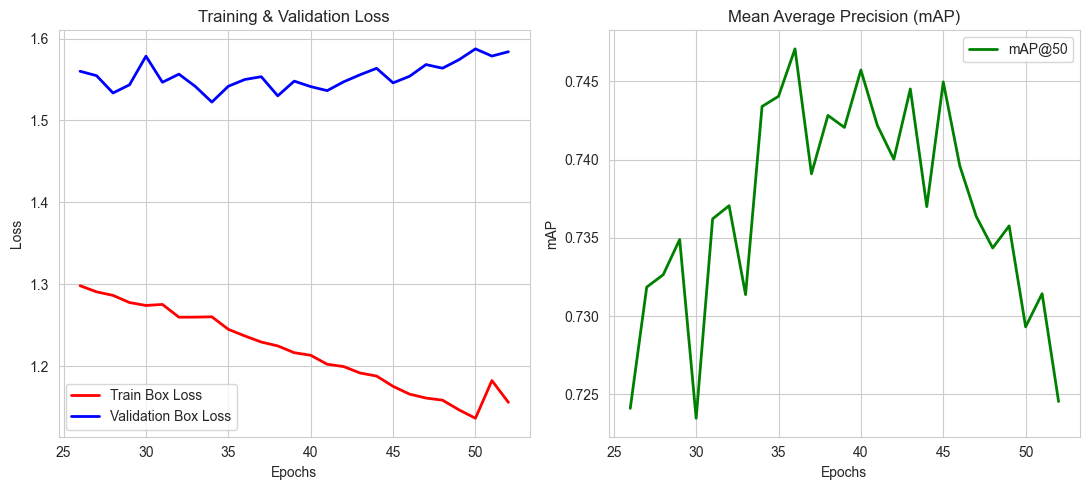

In [5]:
df = pd.read_csv('/content/runs/detect/train/results.csv')

map_column = "metrics/mAP50(B)"
loss_column_train = "train/box_loss"
loss_column_val = "val/box_loss"

plt.figure(figsize=(11,5))

sns.set_style("whitegrid")

plt.subplot(1, 2, 1)
plt.plot(df["epoch"], df[loss_column_train], label="Train Box Loss", color="red", linewidth=2)
plt.plot(df["epoch"], df[loss_column_val], label="Validation Box Loss", color="blue", linewidth=2)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(df["epoch"], df[map_column], label="mAP@50", color="green", linewidth=2)
plt.xlabel("Epochs")
plt.ylabel("mAP")
plt.title("Mean Average Precision (mAP)")
plt.legend()

plt.tight_layout()

plt.show()

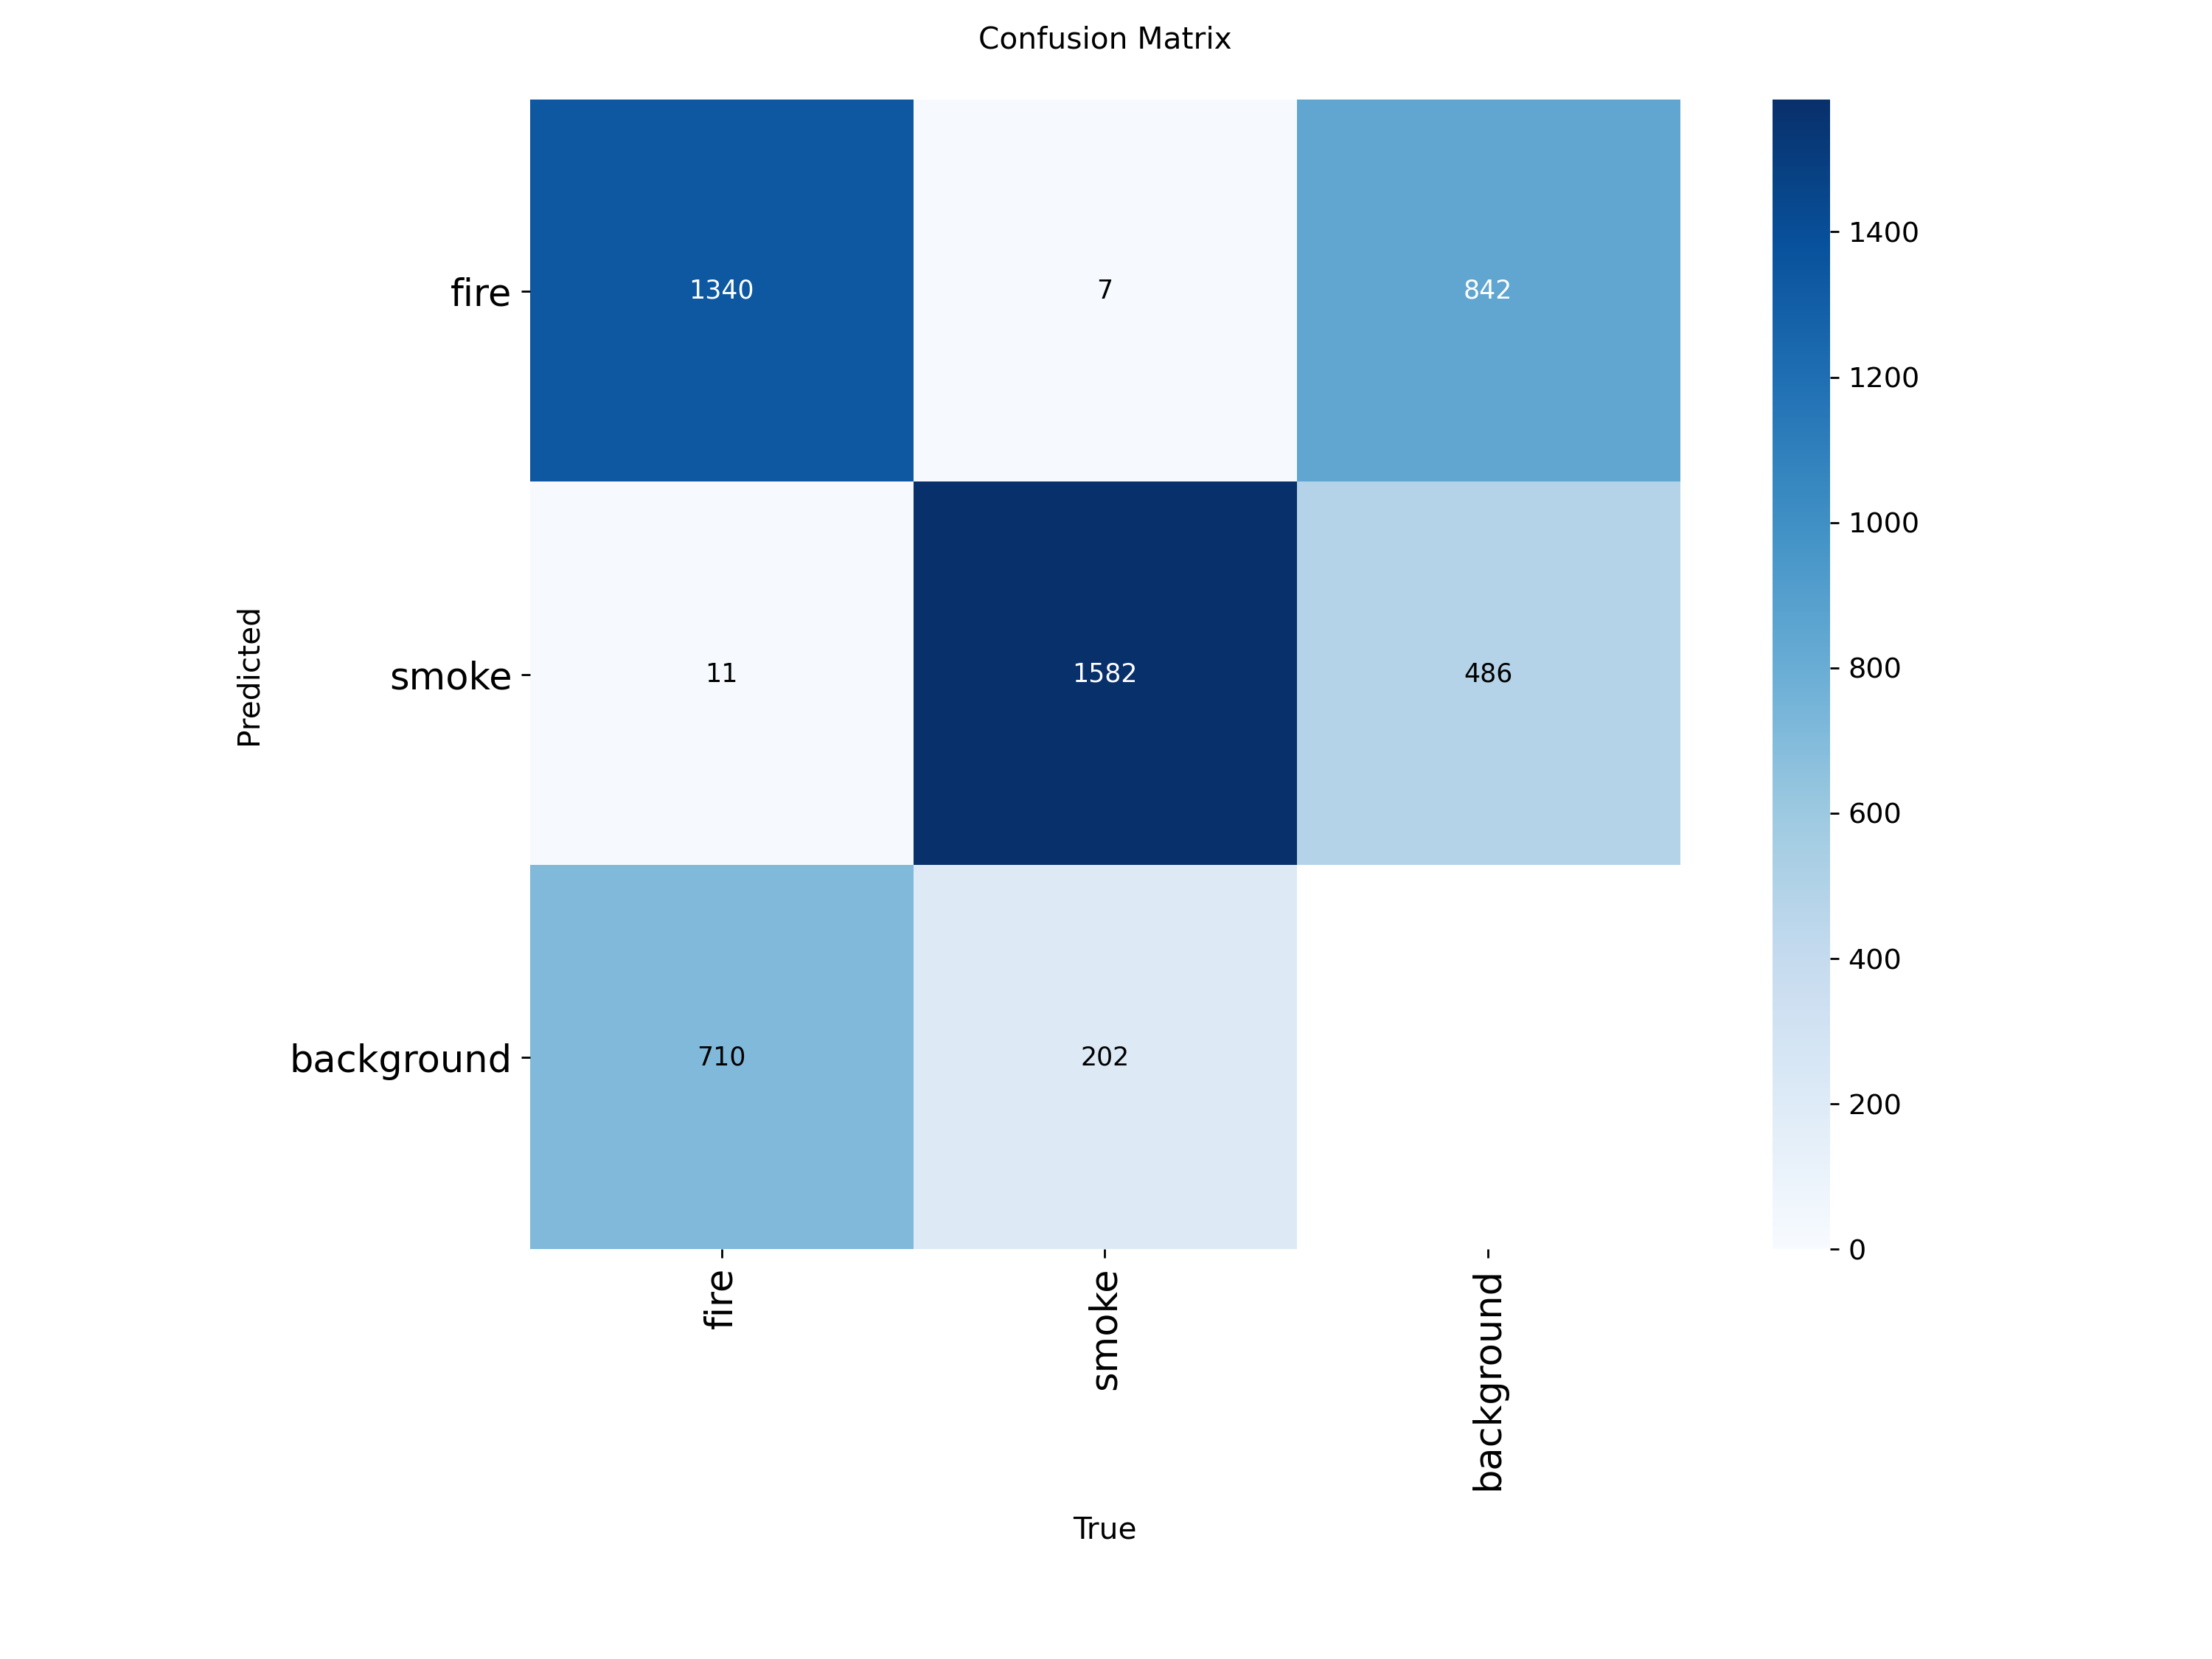

In [10]:
IPyImage(filename=f'/content/runs/detect/val/confusion_matrix.png', width=900)

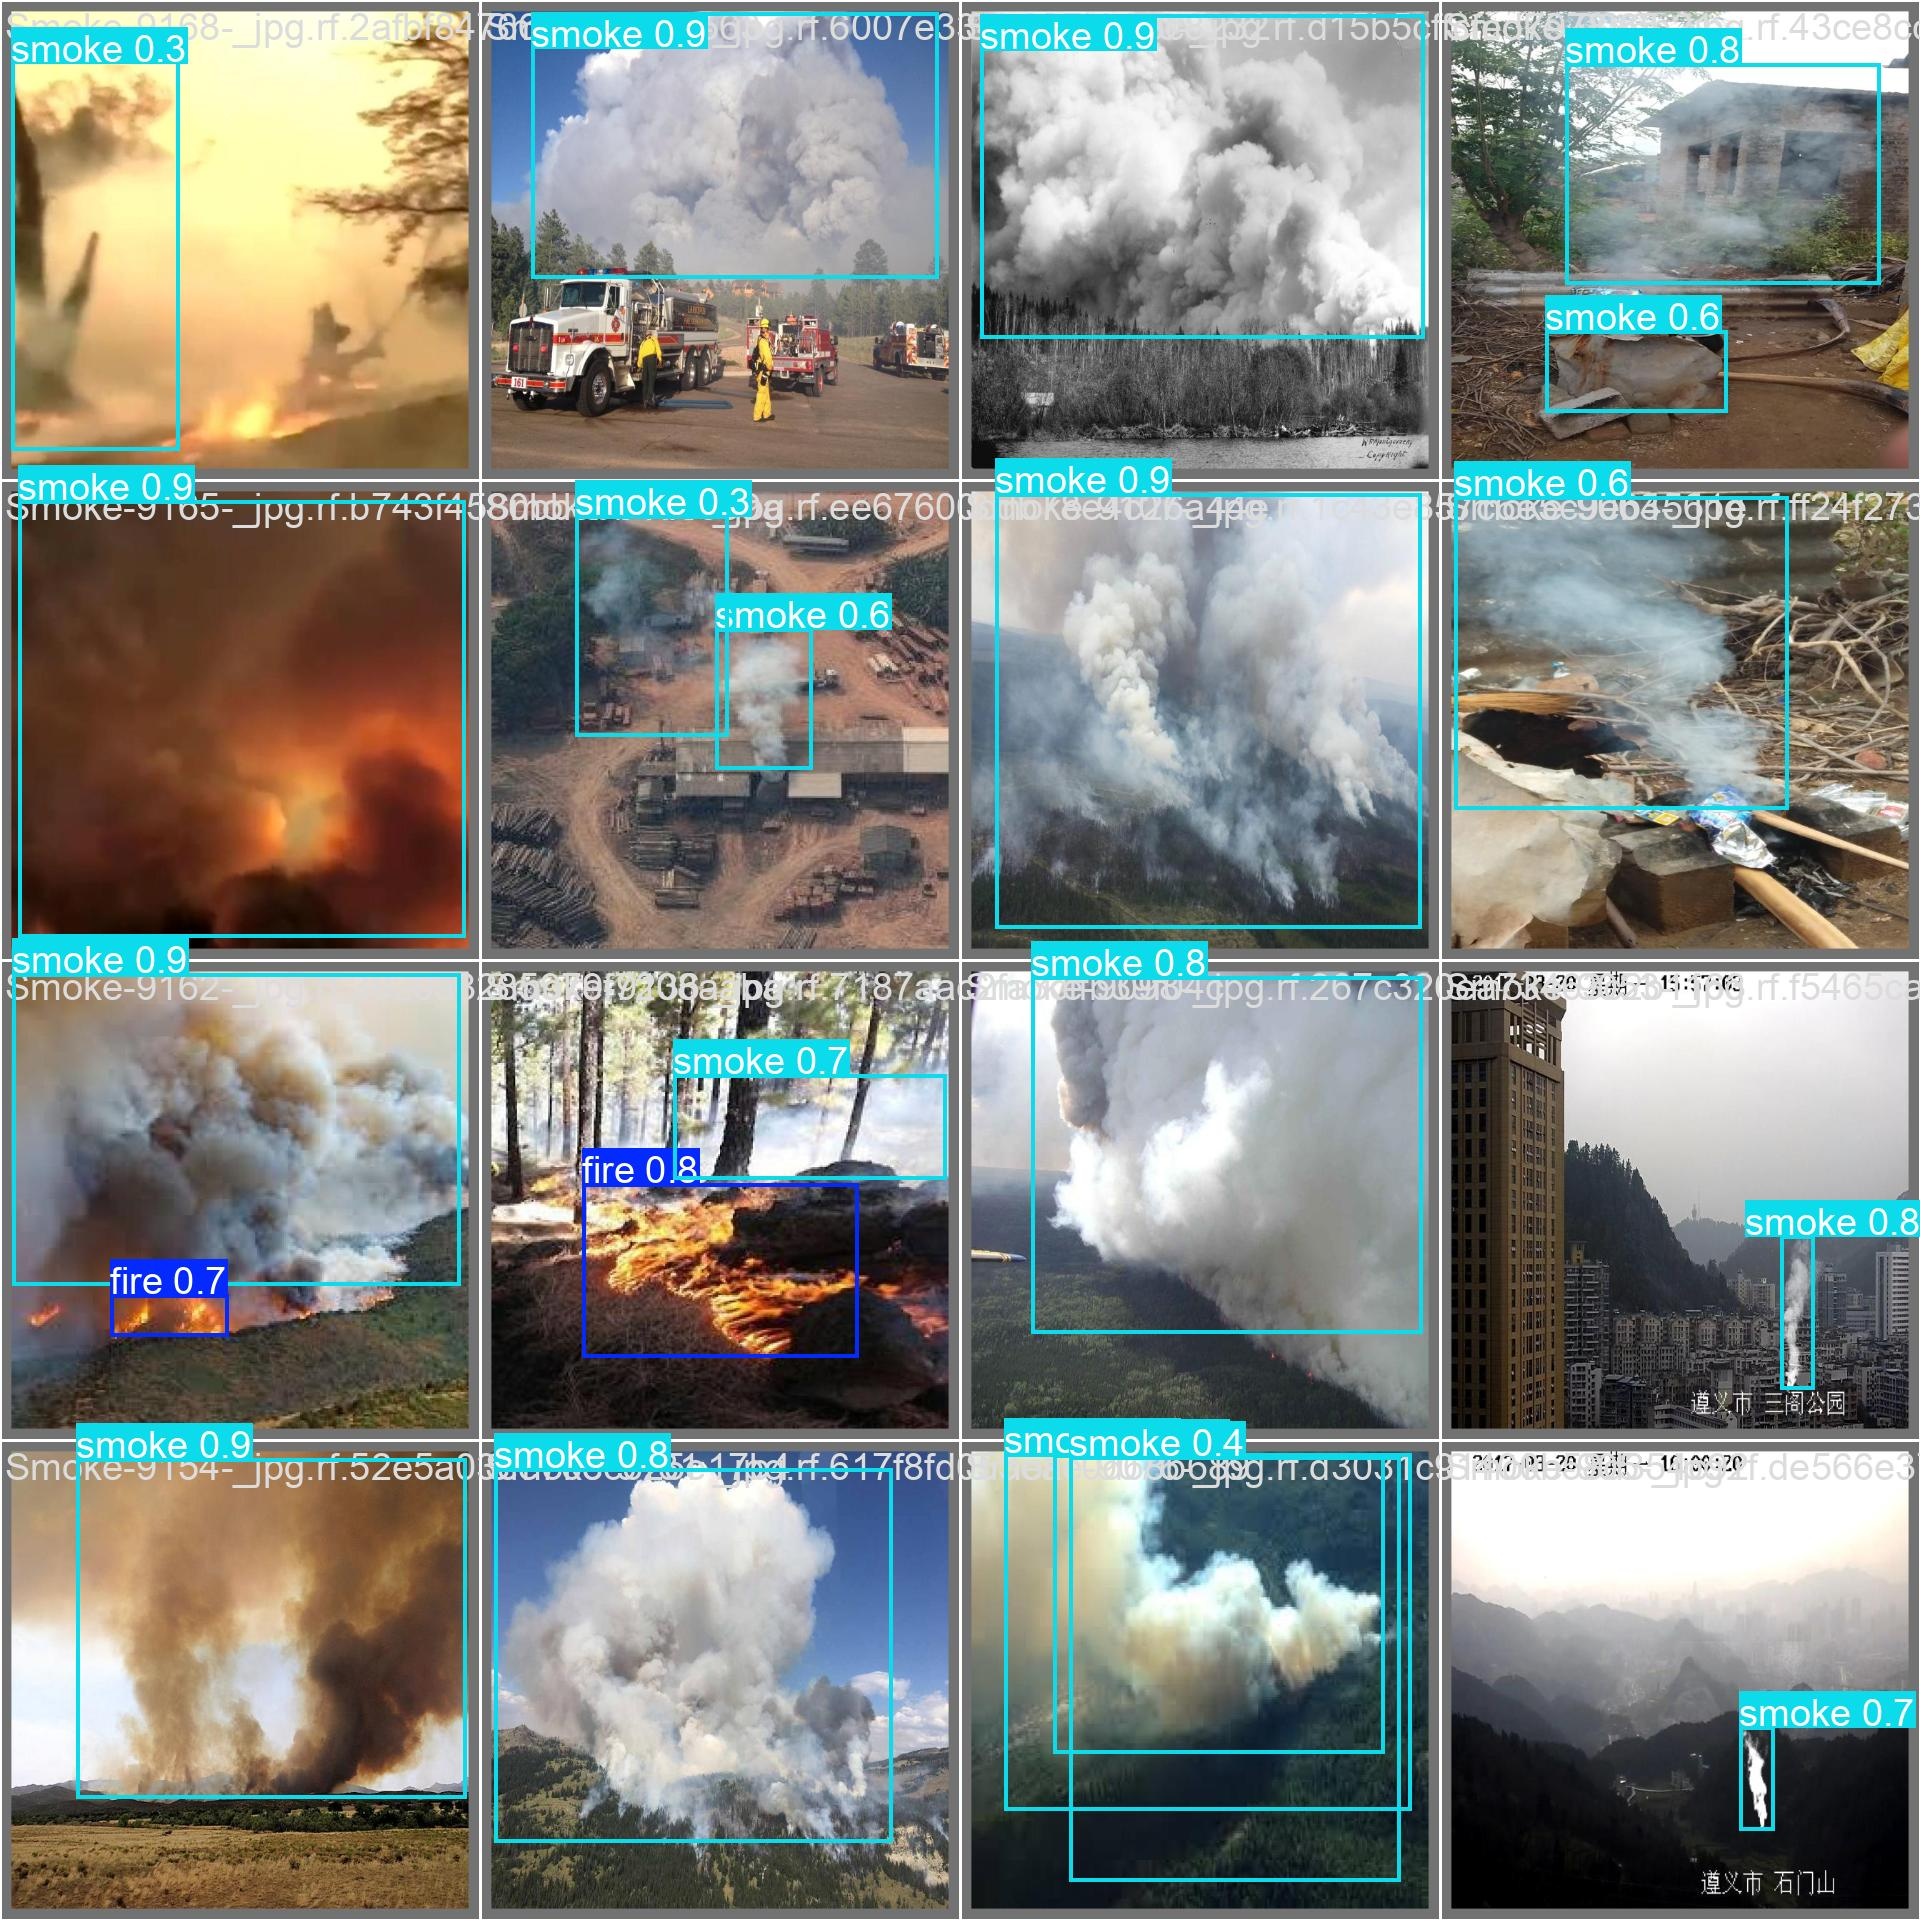

In [11]:
IPyImage(filename=f'/content/runs/detect/val/val_batch0_pred.jpg', width=1200)